In [56]:
!unzip -o sms+spam+collection.zip

Archive:  sms+spam+collection.zip
  inflating: SMSSpamCollection       
  inflating: readme                  


In [57]:
import os
print(os.listdir())

['.config', '.ipynb_checkpoints', 'SMSSpamCollection', 'vectorizer.pkl', 'model.pkl', 'readme', 'sms+spam+collection.zip', 'sample_data']


In [27]:
import pandas as pd

df = pd.read_csv(
    "SMSSpamCollection",
    sep="\t",
    names=["label","message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


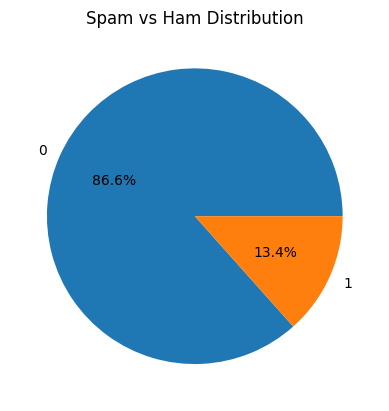

In [46]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Spam vs Ham Distribution")
plt.ylabel("")
plt.show()

In [28]:
print(df.shape)
print(df.head())

(5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [29]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['cleaned'] = df['message'].apply(clean_text)

df.head()

,label,message,cleaned
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


In [30]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

df.head()

,label,message,cleaned
0,0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final...
3,0,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X = vectorizer.fit_transform(df['cleaned'])

y = df['label']

print(X.shape)

(5572, 5000)


In [32]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train,y_train)

print("Model trained")

Model trained


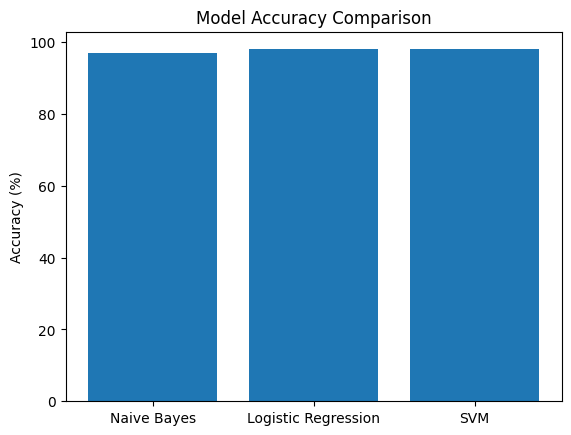

In [52]:
models = ['Naive Bayes','Logistic Regression','SVM']
scores = [97,98,98]

plt.bar(models, scores)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")

plt.show()

In [34]:
from sklearn.metrics import accuracy_score

y_pred = nb.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test,y_pred)
)

Accuracy: 0.9775784753363229


In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[966   0]
 [ 25 124]]


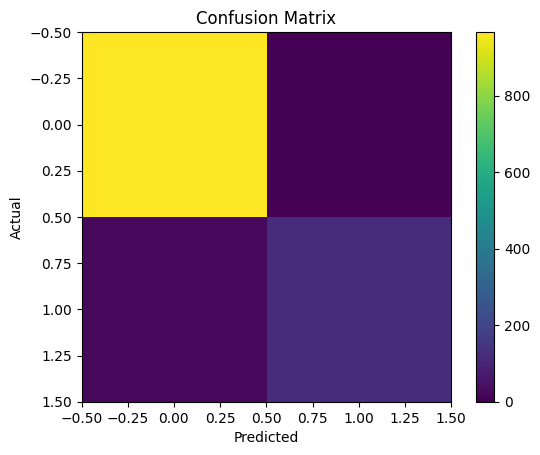

In [51]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [36]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       1.00      0.83      0.91       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [37]:
import re

def detect_url(text):

    pattern = r'https?://\S+'

    return bool(
        re.search(pattern,text)
    )

In [38]:
print(
    detect_url(
        "Click https://google.com"
    )
)

True


In [39]:
phishing_words = [
    "password",
    "bank",
    "login",
    "verify",
    "account"
]

def phishing_check(text):

    text = text.lower()

    for word in phishing_words:

        if word in text:
            return True

    return False

In [40]:
def risk_score(text):

    score = 0

    if detect_url(text):
        score += 50

    if phishing_check(text):
        score += 50

    return score

In [41]:
spam_keywords = [
    "free",
    "winner",
    "urgent",
    "offer",
    "cash",
    "prize"
]

def explain_email(text):

    reasons = []

    for word in spam_keywords:

        if word in text.lower():
            reasons.append(word)

    return reasons

In [42]:
!pip install wordcloud

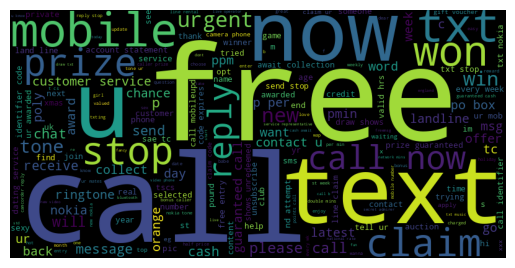

In [43]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

spam_words = " ".join(
    df[df["label"]==1]["cleaned"]
)

wc = WordCloud(
    width=800,
    height=400
).generate(spam_words)

plt.imshow(wc)
plt.axis("off")
plt.show()

In [44]:
email = """
Congratulations!
You are a winner.
Click here:
https://claim-prize.com
"""

data = vectorizer.transform([email])

prediction = nb.predict(data)

print("Spam Prediction:", prediction[0])

print("URL Found:", detect_url(email))

print("Phishing:", phishing_check(email))

print("Risk Score:", risk_score(email))

print("Reasons:", explain_email(email))

Spam Prediction: 1
URL Found: True
Phishing: False
Risk Score: 50
Reasons: ['winner', 'prize']


In [47]:
from collections import Counter

spam_text = " ".join(
    df[df['label']==1]['cleaned']
)

words = spam_text.split()

top_words = Counter(words).most_common(10)

print(top_words)

[('to', 689), ('a', 380), ('call', 350), ('you', 287), ('your', 263), ('free', 219), ('for', 204), ('the', 204), ('now', 190), ('or', 188)]


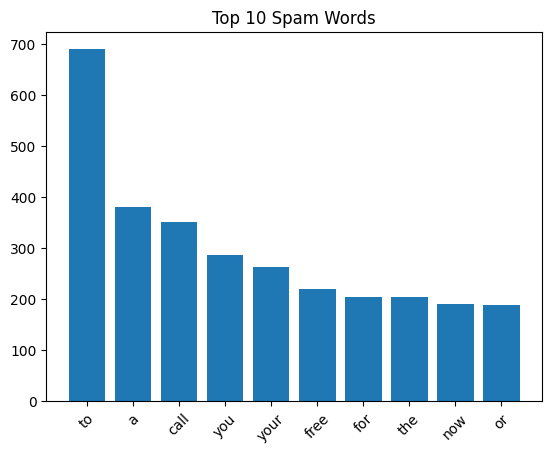

In [48]:
words = [x[0] for x in top_words]
counts = [x[1] for x in top_words]

plt.bar(words, counts)
plt.title("Top 10 Spam Words")
plt.xticks(rotation=45)
plt.show()

In [45]:
import pickle

pickle.dump(
    nb,
    open("model.pkl","wb")
)

pickle.dump(
    vectorizer,
    open("vectorizer.pkl","wb")
)

In [58]:
from google.colab import files

files.download("model.pkl")
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>